## Activation Functions

Goal:
- understand why nonlinearity matters
- learn common activation functions
- build models with activations
- compare activations on simple tasks

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("Pytorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Pytorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


In [2]:
linear1 = nn.Linear(2,3)
linear2 = nn.Linear(3,4)
linear3 = nn.Linear(4,1)

print(linear1)
print(linear2)
print(linear3)

Linear(in_features=2, out_features=3, bias=True)
Linear(in_features=3, out_features=4, bias=True)
Linear(in_features=4, out_features=1, bias=True)


##  A nonlinear activation changes the game


In [3]:
x = torch.linspace(-5, 5, 200)
print(x[:5])
print(x.shape)

tensor([-5.0000, -4.9497, -4.8995, -4.8492, -4.7990])
torch.Size([200])


In [8]:
# Relu
relu = torch.relu(x)
print(relu[:200])
print(relu.shape)


tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0251, 0.0754, 0.1256, 0.1759, 0.2261, 0.2764, 0.3266, 0.3769,
        0.4271, 0.4774, 0.5276, 0.5779, 

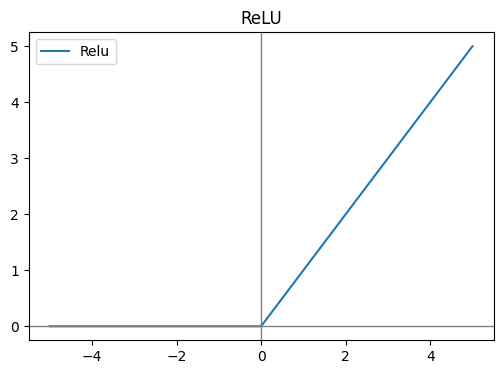

In [6]:
plt.figure(figsize=(6,4))
plt.plot(x.numpy(), relu.numpy(), label="Relu")
plt.axhline(0, color ="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("ReLU")
plt.show()


## Sigmoid

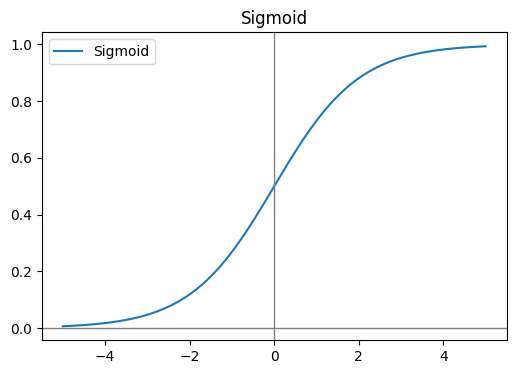

In [9]:
sigmoid = torch.sigmoid(x)
plt.figure(figsize=(6,4))
plt.plot(x.numpy(), sigmoid.numpy(), label="Sigmoid")
plt.axhline(0, color ="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("Sigmoid")
plt.show()

## Tanh

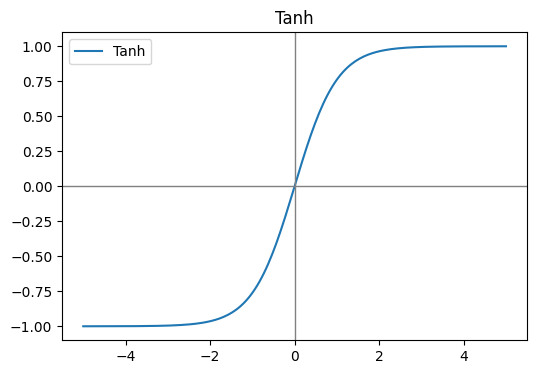

In [10]:
tanh = torch.tanh(x)

plt.figure(figsize=(6, 4))
plt.plot(x.numpy(), tanh.numpy(), label="Tanh")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("Tanh")
plt.show()

## LeakyReLU

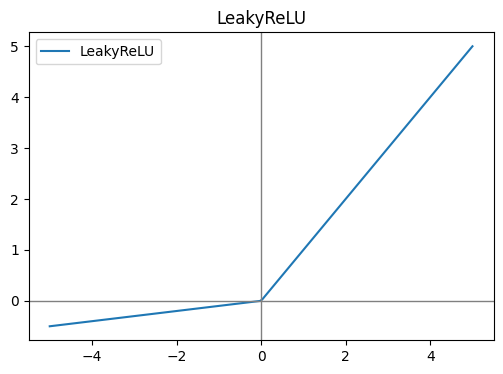

In [13]:
leaky_relu = nn.LeakyReLU(negative_slope=0.1)
y_leaky = leaky_relu(x)

plt.figure(figsize=(6, 4))
plt.plot(x.numpy(), y_leaky.numpy(), label="LeakyReLU")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("LeakyReLU")
plt.show()

## GELU

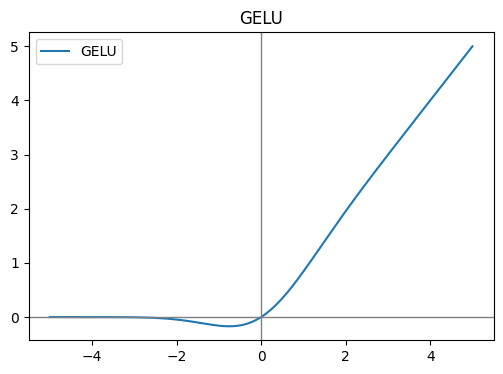

In [14]:
gelu = nn.GELU()
y_gelu = gelu(x)

plt.figure(figsize=(6, 4))
plt.plot(x.numpy(), y_gelu.numpy(), label="GELU")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("GELU")
plt.show()

##  Compare activations together

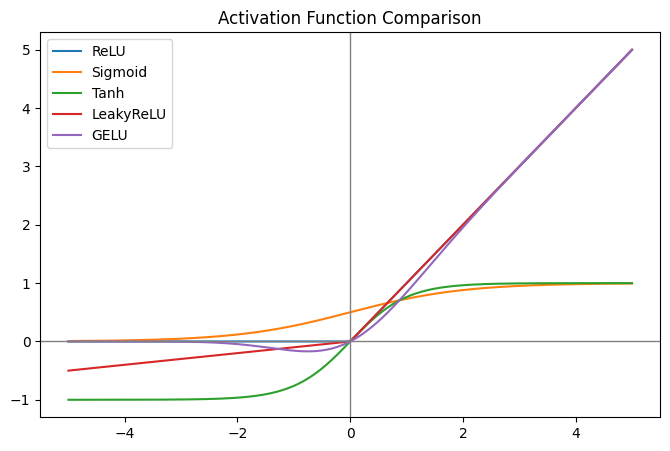

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), torch.relu(x).numpy(), label="ReLU")
plt.plot(x.numpy(), torch.sigmoid(x).numpy(), label="Sigmoid")
plt.plot(x.numpy(), torch.tanh(x).numpy(), label="Tanh")
plt.plot(x.numpy(), leaky_relu(x).numpy(), label="LeakyReLU")
plt.plot(x.numpy(), gelu(x).numpy(), label="GELU")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.legend()
plt.title("Activation Function Comparison")
plt.show()

## Use activations inside a model

In [16]:
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(1,16)
    self.fc2 = nn.Linear(16, 16)
    self.fc3 = nn.Linear(16, 1)

  def forward(self, x):
    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)
    x = torch.relu(x)
    x = self.fc3(x)
    return x


In [17]:
model = SimpleMLP()
print(model)

SimpleMLP(
  (fc1): Linear(in_features=1, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)


In [19]:
torch.manual_seed(42)

X = torch.linspace(-2, 2, 200).reshape(-1,1)
Y = X**2

print(X.shape, Y.shape)
print(X[:5])
print(Y[:5])

torch.Size([200, 1]) torch.Size([200, 1])
tensor([[-2.0000],
        [-1.9799],
        [-1.9598],
        [-1.9397],
        [-1.9196]])
tensor([[4.0000],
        [3.9200],
        [3.8408],
        [3.7624],
        [3.6849]])


## Plot the training data


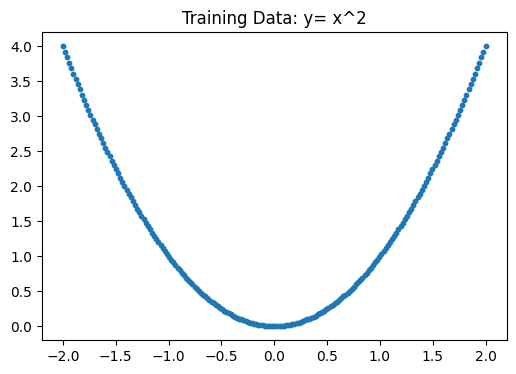

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), Y.numpy(), s=10 )
plt.title("Training Data: y= x^2")
plt.show()


## First try: linear model

In [22]:
linear_model = nn.Linear(1,1)

criterion = nn.MSELoss()
optimizer = optim.SGD(linear_model.parameters(), lr=0.05)

for epoch in range(300):
  preds = linear_model(X)
  loss = criterion(preds, Y)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 50 ==0:
    print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

Epoch 000 | Loss: 2.505042
Epoch 050 | Loss: 1.450852
Epoch 100 | Loss: 1.450845
Epoch 150 | Loss: 1.450844
Epoch 200 | Loss: 1.450844
Epoch 250 | Loss: 1.450844


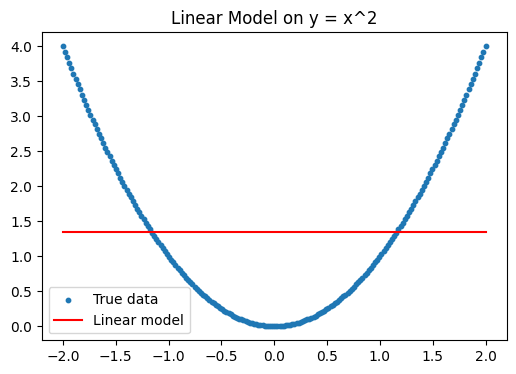

In [23]:
with torch.no_grad():
  linear_preds = linear_model(X)

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10, label="True data")
plt.plot(X.numpy(), linear_preds.numpy(), color="red", label="Linear model")
plt.legend()
plt.title("Linear Model on y = x^2")
plt.show()

## Second try: nonlinear model with ReLU

In [24]:
relu_model = SimpleMLP()

criterion = nn.MSELoss()
optimizer = optim.Adam(relu_model.parameters(), lr=0.01)

for epoch in range(1000):
  preds = relu_model(X)
  loss = criterion(preds, Y)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

Epoch 000 | Loss: 2.867509
Epoch 100 | Loss: 0.025573
Epoch 200 | Loss: 0.005412
Epoch 300 | Loss: 0.001383
Epoch 400 | Loss: 0.000608
Epoch 500 | Loss: 0.000392
Epoch 600 | Loss: 0.000311
Epoch 700 | Loss: 0.000267
Epoch 800 | Loss: 0.000232
Epoch 900 | Loss: 0.000174


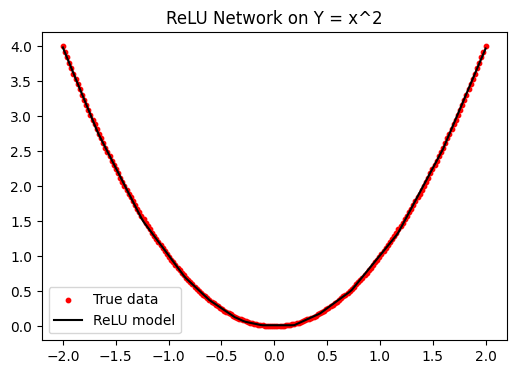

In [28]:
with torch.no_grad():
  relu_preds = relu_model(X)

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), Y.numpy(), s=10, color = "red", label="True data" )
plt.plot(X.numpy(), relu_preds.numpy(), color="black", label="ReLU model")
plt.legend()
plt.title("ReLU Network on Y = x^2")
plt.show()

## Build the same model with Sigmoid

In [41]:
class SigmoidMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.sigmoid(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        x = self.fc3(x)
        return x


In [42]:
sigmoid_model = SigmoidMLP()



In [43]:
criterion = nn.MSELoss()
optimizer = optim.Adam(sigmoid_model.parameters(), lr=0.01)

In [44]:
for epoch in range(1000):
    preds = sigmoid_model(X)
    loss = criterion(preds, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Epoch 0000 | Loss: 4.103891
Epoch 0100 | Loss: 1.335869
Epoch 0200 | Loss: 0.045229
Epoch 0300 | Loss: 0.008016
Epoch 0400 | Loss: 0.005289
Epoch 0500 | Loss: 0.003759
Epoch 0600 | Loss: 0.002494
Epoch 0700 | Loss: 0.001664
Epoch 0800 | Loss: 0.001165
Epoch 0900 | Loss: 0.000838


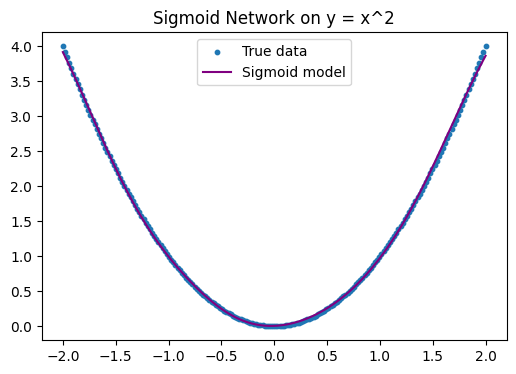

In [45]:
with torch.no_grad():
    sigmoid_preds = sigmoid_model(X)

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10, label="True data")
plt.plot(X.numpy(), sigmoid_preds.numpy(), color="purple", label="Sigmoid model")
plt.legend()
plt.title("Sigmoid Network on y = x^2")
plt.show()

## Build the same model with Tanh

In [46]:
class TanhMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.tanh(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = self.fc3(x)
        return x

In [47]:
tanh_model = TanhMLP()

criterion = nn.MSELoss()
optimizer = optim.Adam(tanh_model.parameters(), lr=0.01)

In [48]:
for epoch in range(1000):
    preds = tanh_model(X)
    loss = criterion(preds, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Epoch 0000 | Loss: 3.767548
Epoch 0100 | Loss: 0.044614
Epoch 0200 | Loss: 0.002667
Epoch 0300 | Loss: 0.001610
Epoch 0400 | Loss: 0.001015
Epoch 0500 | Loss: 0.000594
Epoch 0600 | Loss: 0.000334
Epoch 0700 | Loss: 0.000198
Epoch 0800 | Loss: 0.000128
Epoch 0900 | Loss: 0.000092


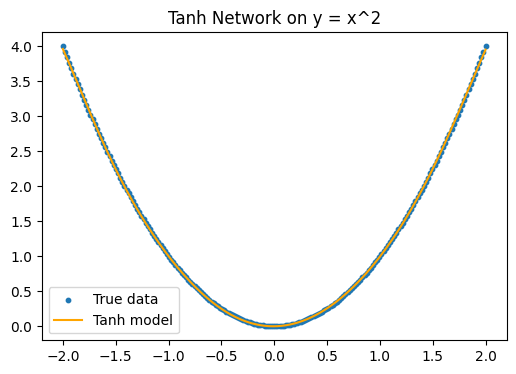

In [49]:
with torch.no_grad():
    tanh_preds = tanh_model(X)

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10, label="True data")
plt.plot(X.numpy(), tanh_preds.numpy(), color="orange", label="Tanh model")
plt.legend()
plt.title("Tanh Network on y = x^2")
plt.show()

## Compare all models

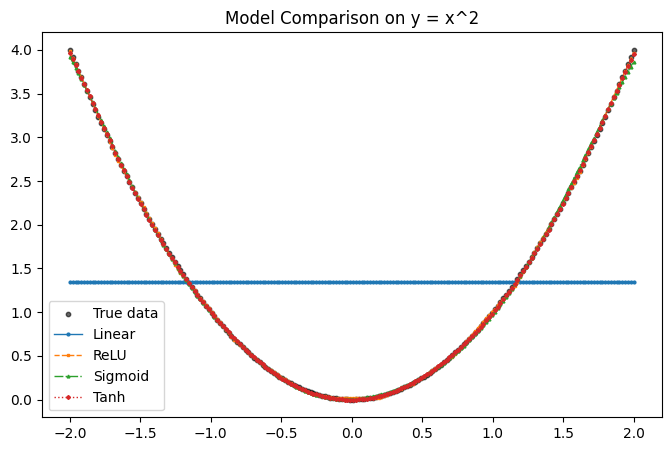

In [55]:
# Define a set of colors that are visually distinct
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Blue, Orange, Green, Red, Purple

plt.figure(figsize=(8, 5))

# Scatter (black with transparency stands out)
plt.scatter(X.numpy(), Y.numpy(), s=10, label="True data", color='black', alpha=0.6)

# Lines with distinct colors + markers + linestyles
plt.plot(X.numpy(), linear_preds.numpy(), label="Linear",
         color=colors[0], linestyle='-', marker='o', markersize=2, linewidth=1)
plt.plot(X.numpy(), relu_preds.numpy(), label="ReLU",
         color=colors[1], linestyle='--', marker='s', markersize=2, linewidth=1)
plt.plot(X.numpy(), sigmoid_preds.numpy(), label="Sigmoid",
         color=colors[2], linestyle='-.', marker='^', markersize=2, linewidth=1)
plt.plot(X.numpy(), tanh_preds.numpy(), label="Tanh",
         color=colors[3], linestyle=':', marker='D', markersize=2, linewidth=1)

plt.legend()
plt.title("Model Comparison on y = x^2")
plt.show()

## Sequential style

In [56]:
sequential_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(sequential_model)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


## Custom activation function with nn.Module

In [57]:
class SquareActivation(nn.Module):
  def forward(self, x):
    return x**2

In [58]:
square_activation = SquareActivation()

x_small = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print(square_activation(x_small))

tensor([4., 1., 0., 1., 4.])


##  Use custom activation in a model

In [60]:
custom_model = nn.Sequential(
    nn.Linear(1,8),
    SquareActivation(),
    nn.Linear(8,1)
)

print(custom_model)

Sequential(
  (0): Linear(in_features=1, out_features=8, bias=True)
  (1): SquareActivation()
  (2): Linear(in_features=8, out_features=1, bias=True)
)


## Gradient check through an activation

In [61]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.relu(x)

y.backward()
print("x.grad =", x.grad)

x.grad = tensor(1.)


## Production habit: write a reusable train function

In [64]:
def train_model(model, X, Y, epochs=500, lr=0.01, device="cpu"):
  model = model.to(device)
  X = X.to(device)
  Y= Y.to(device)

  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  loss_history = []

  for epoch in range(epochs):
    preds = model(X)
    loss = criterion(preds, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 100 ==0:
      print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

  return model, loss_history

In [65]:
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

model, loss_history = train_model(model, X, Y, epochs=500, lr=0.01, device=device)

Epoch 000 | Loss: 3.231634
Epoch 100 | Loss: 0.056001
Epoch 200 | Loss: 0.008994
Epoch 300 | Loss: 0.002484
Epoch 400 | Loss: 0.001198


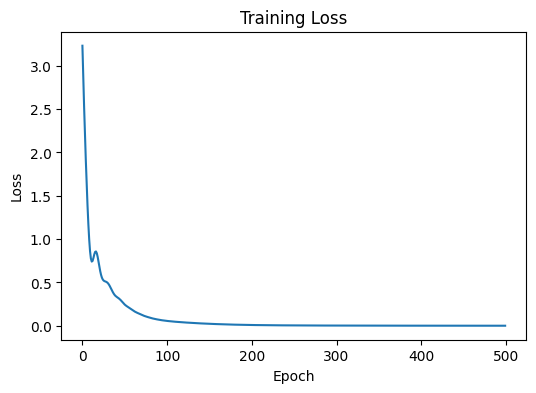

In [66]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Production habit: save model weights

In [67]:
torch.save(model.state_dict(), "activation_model.pth")
print("model saved")

model saved
